# Classical

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
import pandas as pd
import numpy as np
import prince
import os
from datetime import datetime
from ucimlrepo import fetch_ucirepo
pd.set_option('display.max_columns', None)
from IPython import get_ipython
from QuECOC import build_ecoc_matrix

def play_cell_sound(result):
    os.system("powershell.exe -c '(New-Object Media.SoundPlayer \"C:\\Windows\\Media\\notify.wav\").PlaySync()'")
    
ip = get_ipython()
try:
    ip.events.unregister('post_run_cell', play_cell_sound)
except ValueError:
    pass
ip.events.register('post_run_cell', play_cell_sound)

In [6]:
lab_train = pd.read_csv('datasets/misc/lab1-train-processed.csv')
lab_test = pd.read_csv('datasets/misc/lab1-test-processed.csv')

display(lab_train)
display(lab_test)

y_train = lab_train['class']
y_test = lab_test['class']
X_train = lab_train.drop('class', axis=1)
X_test = lab_test.drop('class', axis=1)

top_cols = [col for col in X_train.columns if col.startswith('X')]
famd_cols = [col for col in X_train.columns if col.startswith('C')]

,class,X2,C0,X6,C1,X10,C2,X17,C3,X3,C4,X4,C5,X7,C6,X5_1,C7,X13,C8,X15_1,C9
0,6,133.907314,-1.468208,2.989235,0.276903,1.745602,-1.991880,18.008365,1.665992,3.000000,0.229429,0.625350,0.430481,2.923792,-0.388358,0,-0.027717,1.536555,0.191164,0,0.392011
1,4,82.365608,0.714526,1.810804,-0.618230,1.608400,-1.650259,22.339190,-1.390567,1.000000,0.296710,2.000000,1.706740,2.598632,1.324411,0,-0.891510,0.292093,0.010644,0,0.161591
2,5,121.134488,-2.238483,2.811050,0.281797,1.867410,-0.672576,23.274485,0.569318,2.657720,0.563710,0.000000,-0.540056,2.104696,-0.125796,1,0.702596,0.870056,-0.008144,0,-0.410528
3,3,79.125521,0.405247,2.000000,1.650545,1.800000,-0.510070,17.652645,-1.338986,1.000000,1.324808,1.000000,-0.165750,2.000000,0.540286,1,0.183907,2.000000,-0.076974,1,-0.326369
4,5,118.193323,-2.002027,2.191108,0.604417,1.788586,-0.415796,24.566325,0.107035,2.993856,0.729268,0.145284,-0.443735,2.444917,-0.272059,1,0.404912,1.388962,-0.046416,0,-0.086728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1683,3,66.859042,1.451516,2.000000,0.303109,1.640000,0.447478,21.226280,-1.254997,3.000000,-1.246056,1.000000,-0.086139,1.000000,-0.521961,1,-0.363859,0.000000,-0.504150,0,-1.602967
1684,4,98.739188,-0.881631,2.000000,1.897943,1.732694,-0.426703,21.494374,-1.222413,2.993623,-0.707082,1.529423,0.645786,2.326635,-0.720979,1,-1.006865,2.236586,0.317045,0,-0.150458
1685,4,95.973811,-1.011257,2.000000,2.155115,1.741353,-0.333581,21.005434,-0.944677,3.000000,-0.354342,1.229474,0.727815,2.697661,-1.109787,1,-0.995599,2.614909,0.431379,0,-0.052324
1686,0,79.634810,-1.090697,1.993101,0.495533,1.745950,-0.022242,24.969213,-0.348468,3.171082,0.713230,0.022245,-0.693482,2.364498,-0.282761,1,0.378846,1.224743,-0.208985,0,0.082620


,class,X2,C0,X6,C1,X10,C2,X17,C3,X3,C4,X4,C5,X7,C6,X5_1,C7,X13,C8,X15_1,C9
0,0,65.517027,0.484487,2.374640,-1.847356,1.449559,1.590055,36.591143,0.396030,3.000000,-0.189425,0.480813,0.340385,2.000000,-1.107690,0,-0.227402,2.892922,0.179947,0,1.047396
1,4,80.321076,0.109128,2.766320,-3.276887,1.582523,2.075080,42.412773,-0.221815,1.317884,-0.121852,0.000000,1.570310,1.967408,-1.178837,0,-0.372068,0.990642,0.527927,0,-0.123479
2,6,103.939346,0.073094,3.000000,-1.897598,1.617390,-1.372753,24.228630,0.688670,3.000000,-0.626943,0.541309,-0.320001,1.292479,0.558842,0,0.421557,0.000000,-0.395995,0,-0.056059
3,3,64.881769,-0.796613,3.000000,1.193776,1.780000,1.134938,24.192968,0.908599,3.000000,-0.281191,1.000000,0.873024,2.000000,2.358295,1,-2.152621,1.000000,0.820595,0,2.345712
4,4,103.919796,-1.670365,2.253707,0.339208,1.785718,-0.616425,23.199143,-0.033524,3.000000,0.776164,0.175694,-0.464756,2.524432,0.078508,1,0.435049,0.582160,-0.180257,0,0.012671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,6,106.455606,-0.521648,3.009608,-1.567272,1.629191,-1.414409,27.070496,1.220609,3.000000,0.150220,0.555468,0.401723,2.654702,0.222386,0,0.132335,0.000000,-0.099324,0,0.446954
419,3,60.350897,0.979537,2.000000,0.074900,1.650000,0.661700,22.742513,-0.687676,3.000000,-0.106647,0.000000,0.040351,2.000000,-1.063919,1,-0.124470,0.000000,-0.350357,0,-1.211942
420,4,95.104136,-0.641643,2.000000,1.167839,1.701986,-0.225637,22.698244,-1.236276,3.000000,-0.591072,1.066603,0.349936,2.021270,-0.624453,1,-0.686549,1.814869,0.152797,0,-0.284635
421,4,80.293832,0.202996,2.000000,-3.692421,1.529060,1.813763,40.067806,-0.553698,3.000000,-0.338952,0.000000,-0.623399,1.000000,0.189557,0,0.530507,0.000000,-0.555358,0,0.418316


In [7]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.38      0.45        58
           1       0.52      0.50      0.51        58
           2       0.78      0.98      0.87        54
           3       0.48      0.45      0.46        58
           4       0.74      0.60      0.66        70
           5       0.72      0.97      0.83        60
           6       0.94      1.00      0.97        65

    accuracy                           0.70       423
   macro avg       0.68      0.70      0.68       423
weighted avg       0.68      0.70      0.68       423



In [ ]:
model = SVC(kernel='rbf', class_weight='balanced')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("SVC Classification Report:")
print(classification_report(y_test, y_pred))

SVC Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.53      0.57        58
           1       0.68      0.76      0.72        58
           2       0.81      0.96      0.88        54
           3       0.62      0.64      0.63        58
           4       0.94      0.69      0.79        70
           5       0.85      0.97      0.91        60
           6       1.00      1.00      1.00        65

    accuracy                           0.79       423
   macro avg       0.79      0.79      0.79       423
weighted avg       0.80      0.79      0.79       423



In [ ]:
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.72      0.78        58
           1       0.81      0.88      0.84        58
           2       0.93      0.96      0.95        54
           3       0.78      0.86      0.82        58
           4       0.96      0.91      0.93        70
           5       1.00      0.97      0.98        60
           6       1.00      1.00      1.00        65

    accuracy                           0.90       423
   macro avg       0.90      0.90      0.90       423
weighted avg       0.91      0.90      0.90       423



In [ ]:
ecoc = build_ecoc_matrix(7, 14)

final_preds = np.array([[0] * ecoc.shape[1]] * len(y_test))
for i, code in enumerate(ecoc):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(X_train_scaled, y_train.apply(lambda x: code[x]))
    y_pred = clf.predict(X_test_scaled)

    # # Individual classification report for each binary classifier
    # print(f"Classifier {i+1} (Code: {code}):")
    # print(classification_report(y_test.apply(lambda x: code[x]), y_pred))

    for j, pred in enumerate(y_pred):
        final_preds[j][code == pred] += 1

final_preds = np.argmax(final_preds, axis=1)
print("Logistic Regression Ensemble Classification Report:")
print(classification_report(y_test, final_preds, zero_division=0))

Logistic Regression Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.10      0.14        58
           1       1.00      0.02      0.03        58
           2       0.32      0.78      0.45        54
           3       0.00      0.00      0.00        58
           4       0.00      0.00      0.00        70
           5       0.26      0.73      0.39        60
           6       0.41      0.57      0.47        65

    accuracy                           0.31       423
   macro avg       0.32      0.31      0.21       423
weighted avg       0.31      0.31      0.21       423



In [ ]:
ecoc = build_ecoc_matrix(7, 14)

final_preds = np.array([[0] * ecoc.shape[1]] * len(y_test))
for i, code in enumerate(ecoc):
    clf = SVC(kernel='rbf', class_weight='balanced')
    clf.fit(X_train_scaled, y_train.apply(lambda x: code[x]))
    y_pred = clf.predict(X_test_scaled)

    # # Individual classification report for each binary classifier
    # print(f"Classifier {i+1} (Code: {code}):")
    # print(classification_report(y_test.apply(lambda x: code[x]), y_pred))

    for j, pred in enumerate(y_pred):
        final_preds[j][code == pred] += 1

final_preds = np.argmax(final_preds, axis=1)
print("SVC Ensemble Classification Report:")
print(classification_report(y_test, final_preds, zero_division=0))

SVC Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.28      0.30        58
           1       0.18      0.03      0.06        58
           2       0.58      0.61      0.59        54
           3       0.54      0.52      0.53        58
           4       0.43      0.49      0.46        70
           5       0.56      0.73      0.63        60
           6       0.60      0.86      0.70        65

    accuracy                           0.51       423
   macro avg       0.46      0.50      0.47       423
weighted avg       0.46      0.51      0.47       423



# Quantum

In [2]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import IQPEmbedding, StronglyEntanglingLayers
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from QuECOC import VQC, QuantumECOC, StackedECOC, CoherentECOC, reuploading_qlayer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = "cpu"

print(f"Using device: {DEVICE}\n")
qml.about()

Using device: cpu

Name: pennylane
Version: 0.45.0
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: /home/edwar/.pyenv/versions/3.14.5/lib/python3.14/site-packages
Platform info:           Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
Python version:          3.14.5
Numpy version:           2.4.6
Scipy version:           1.17.1
JAX version:             None
Catalyst version:        None
Installed devices:
- lightning.gpu (pennylane_lightning_gpu-0.45.0)
- default.clifford (pennylane-0.45.0)
- default.gaussian (pennylane-0.45.0)
- default.mixed (pennylane-0.45.0)
- default.qubit (pennylane-0.45.0)
- default.qutrit (pennylane-0.45.0)
- default.qutrit.mixed (pennylane-0.45.0)
- default.tensor (pennylane-0.45.0)
- null.qubit (pennylane-0.45.0)
- reference.qubit (pennylane-0.45.0)
- lightning.qubit (pe

In [ ]:
n_qubits = 2
n_layers = 2

if DEVICE == "cuda":
    dev = qml.device("lightning.gpu", wires=n_qubits)
else:
    dev = qml.device("default.qubit", wires=n_qubits)
    
scaler = MinMaxScaler(feature_range=(0, np.pi))

<default.qubit device (wires=2) at 0x73398af8b9d0>


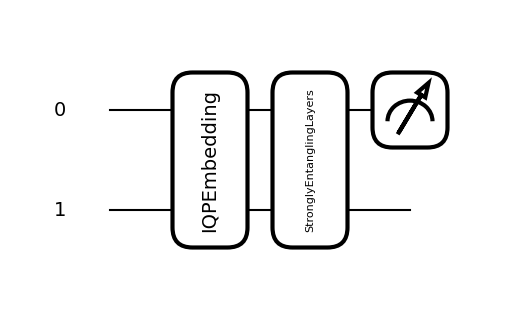

In [ ]:
@qml.qnode(dev, interface='torch', diff_method='best')
def circuit(inputs: torch.Tensor, weights: torch.Tensor) -> qml.measurements.ProbabilityMP:
    IQPEmbedding(inputs, wires=range(n_qubits), n_repeats=2)
    StronglyEntanglingLayers(weights, wires=range(n_qubits))

    return qml.probs(wires=[0])

weight_shapes = {
    "weights": (n_layers, n_qubits, 3)
}

qml.draw_mpl(circuit)(np.zeros(n_qubits), np.zeros(weight_shapes["weights"]))
print(circuit.device)

qlayer = qml.qnn.TorchLayer(circuit, weight_shapes=weight_shapes)

(<Figure size 4500x500 with 1 Axes>, <Axes: >)

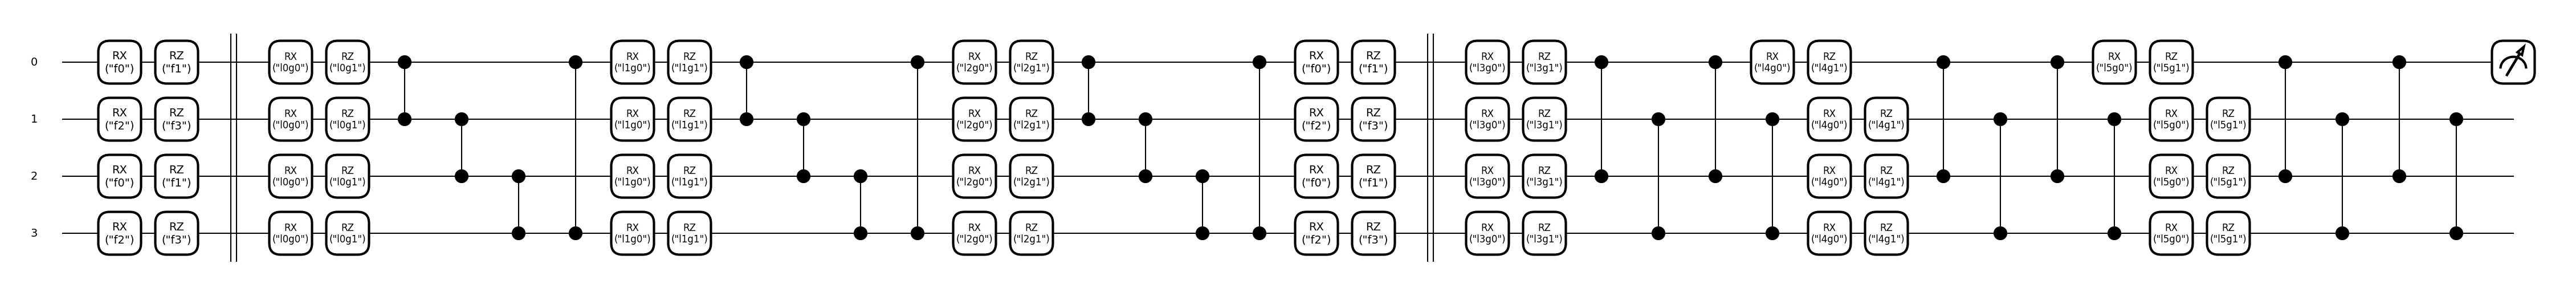

In [ ]:
device = qml.device("default.qubit", wires=2)
qubits = 4
qlayer, circuit, weight_shapes, _ = reuploading_qlayer(
    n_qubits=qubits,
    feats_per_qubit=2,
    device=device,
    reuploads=2,
    entangle_between_reuploads=True,
    trainable_layers=3,
    ranges=[1,2],
    measurement_wires=[0]
)
qml.draw_mpl(circuit)(np.zeros(qubits), np.zeros(weight_shapes["weights"]))

In [ ]:
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets
label_names = sorted(y[y.columns[0]].unique())
label_to_int = {label: idx for idx, label in enumerate(label_names)}
int_to_label = {idx: label for idx, label in enumerate(label_names)}
print(f"Label mapping: {label_to_int}")
y = y[y.columns[0]].map(label_to_int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

pca = prince.PCA(n_components=2, n_iter=5, random_state=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

Label mapping: {'B': 0, 'M': 1}


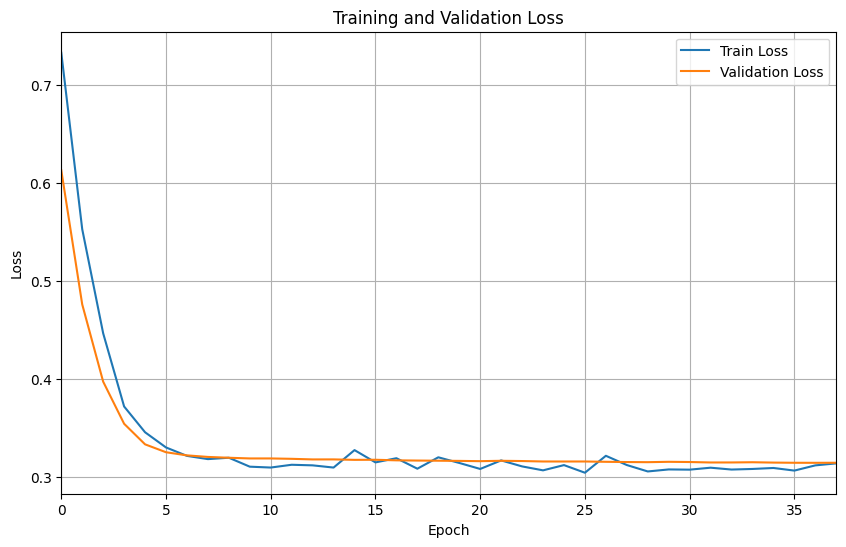

[Epoch 38/100] Train Loss: 0.3139 | Val Loss: 0.3145 | Val Acc: 0.930
Early stopping at epoch 38
Training time: 6.05 seconds


In [ ]:
model = VQC().to(DEVICE)
model.fit(X_train, y_train, plot=True, verbose=True)

In [ ]:
train_score = model.score(X_train, y_train)

print(f"Training Accuracy: {train_score:.2f}")
print("Testing Classification Report:\n", classification_report(y_test, model.predict(X_test), zero_division=0))

Training Accuracy: 0.91
Testing Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94        72
           1       1.00      0.79      0.88        42

    accuracy                           0.92       114
   macro avg       0.94      0.89      0.91       114
weighted avg       0.93      0.92      0.92       114



## Ensemble

In [ ]:
X = pd.read_csv("datasets/0/iris.csv")
y = X["target"]
X = X.drop("target", axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

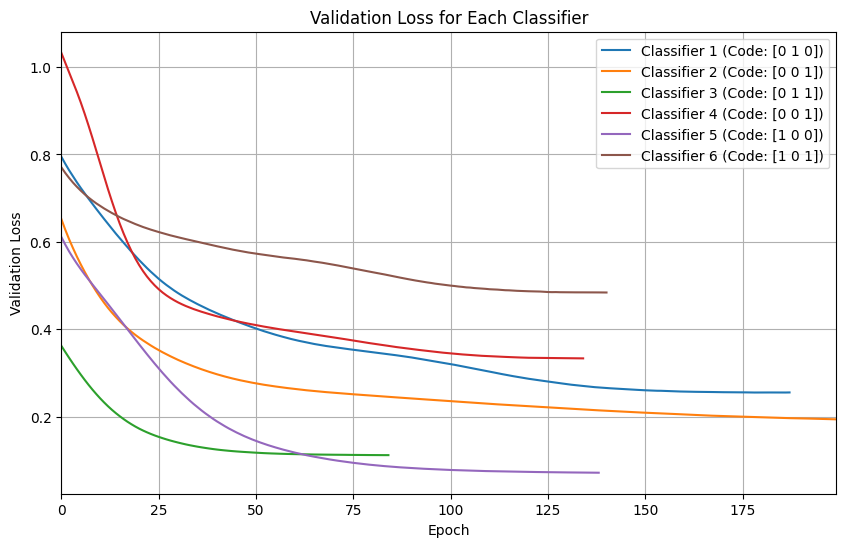


Total training time after fitting 6 classifiers: 1m 24.00s


In [ ]:
ens = QuantumECOC().to(DEVICE)
ens.fit(X_train, y_train, X_test, y_test, epochs=200, plot=True, verbose=True)

In [ ]:
train_score = ens.score(X_train, y_train)

print(f"Training Accuracy: {train_score:.2f}")
print("Testing Classification Report:\n", classification_report(y_test, ens.predict(X_test), zero_division=0))

Training Accuracy: 0.91
Testing Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



In [ ]:
lab_train = pd.read_csv('datasets/misc/lab1-train-processed.csv')
lab_test = pd.read_csv('datasets/misc/lab1-test-processed.csv')

y_train = lab_train['class']
y_test = lab_test['class']
X_train = lab_train.drop('class', axis=1)
X_test = lab_test.drop('class', axis=1)

top_cols = [col for col in X_train.columns if col.startswith('X')]
famd_cols = [col for col in X_train.columns if col.startswith('C')]

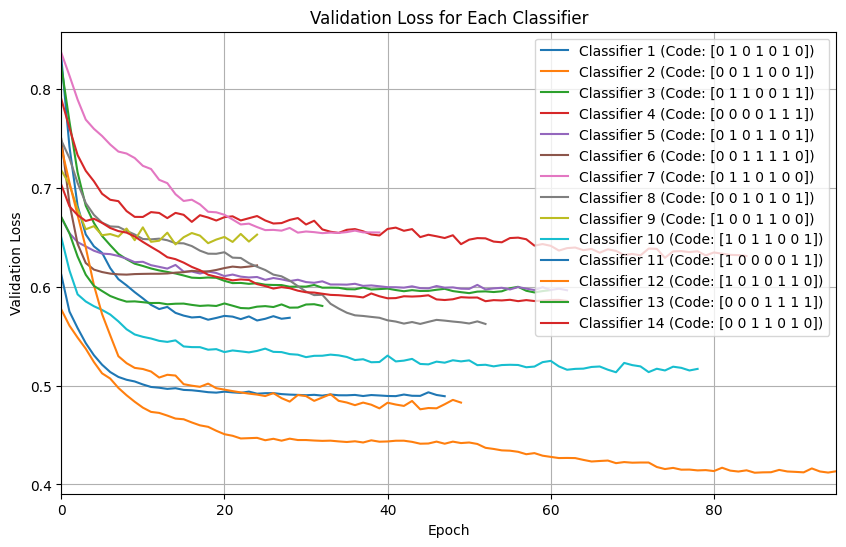


Total training time after fitting 14 classifiers: 3m 31.00s


In [ ]:
ens = QuantumECOC(templates=1).to(DEVICE)
ens.fit(X_train, y_train, X_test, y_test, epochs=200, plot=True, verbose=True)

In [ ]:
train_score = ens.score(X_train, y_train)

print(f"Training Accuracy: {train_score:.2f}")
print("Testing Classification Report:\n", classification_report(y_test, ens.predict(X_test), zero_division=0))

Training Accuracy: 0.53
Testing Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.09      0.14        58
           1       0.36      0.36      0.36        58
           2       0.62      0.74      0.67        54
           3       0.28      0.16      0.20        58
           4       0.53      0.60      0.56        70
           5       0.48      0.73      0.58        60
           6       0.79      1.00      0.88        65

    accuracy                           0.53       423
   macro avg       0.48      0.53      0.49       423
weighted avg       0.49      0.53      0.49       423



## Classical Meta Learner

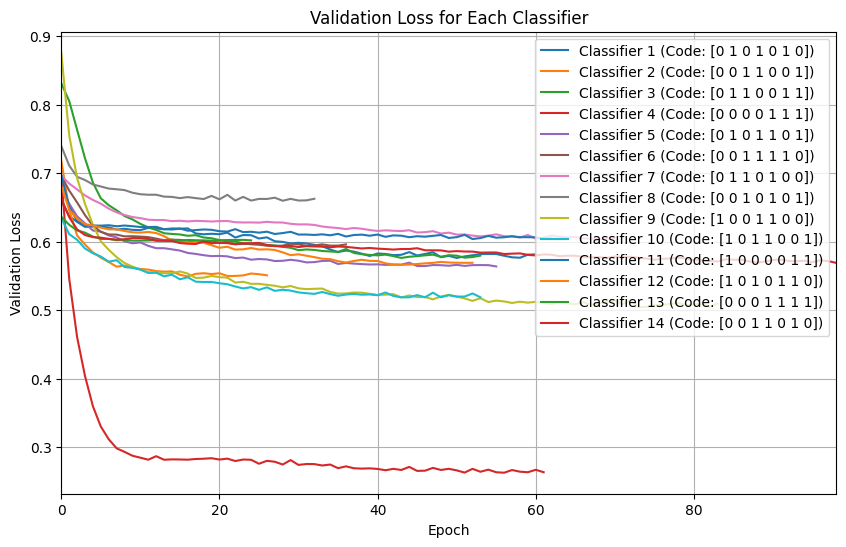


Total training time after fitting 14 classifiers across 5 folds: 14m 9.00s


In [ ]:
ens = StackedECOC(templates=1).to(DEVICE)
ens.fit(X_train, y_train, X_test, y_test, epochs=200, plot=True, verbose=True)

In [ ]:
train_score = ens.score(X_train, y_train)

print(f"Training Accuracy: {train_score:.2f}")
print("Testing Classification Report:\n", classification_report(y_test, ens.predict(X_test), zero_division=0))

Training Accuracy: 0.77
Testing Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.45      0.44        58
           1       0.55      0.38      0.45        58
           2       0.84      0.91      0.88        54
           3       0.48      0.47      0.47        58
           4       0.68      0.77      0.72        70
           5       0.86      0.95      0.90        60
           6       1.00      1.00      1.00        65

    accuracy                           0.71       423
   macro avg       0.69      0.70      0.70       423
weighted avg       0.70      0.71      0.70       423



## Quantum Meta Learner

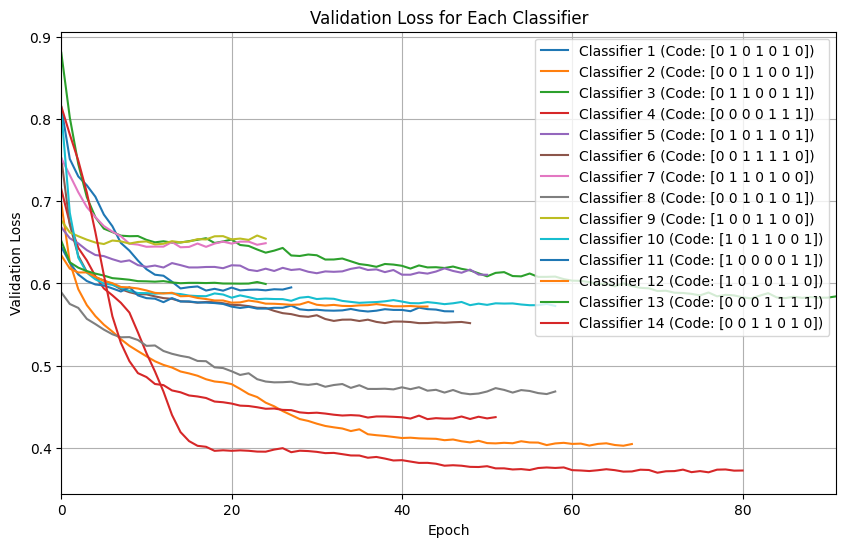


Total training time after fitting 14 classifiers across 5 folds: 17m 15.00s


In [ ]:
c = len(np.unique(y_train))
metaVQC = VQC(n_classes=c, template='manual',
            n_qubits=c // 3 + 1,
            feats_per_qubit=3,
            reuploads=3,
            entangle_between_reuploads=True,
            trainable_layers=[1, 2, 3],
            # measurement_wires=[0]
        ).to(DEVICE)
ens = StackedECOC(meta_learner=metaVQC, templates=1)
ens.fit(X_train, y_train, X_test, y_test, epochs=200, plot=True, verbose=True)

In [ ]:
train_score = ens.score(X_train, y_train)

print(f"Training Accuracy: {train_score:.2f}")
print("Testing Classification Report:\n", classification_report(y_test, ens.predict(X_test), zero_division=0))

Training Accuracy: 0.58
Testing Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.16      0.21        58
           1       0.24      0.12      0.16        58
           2       0.64      0.91      0.75        54
           3       0.33      0.10      0.16        58
           4       0.35      0.74      0.47        70
           5       0.75      0.72      0.74        60
           6       1.00      1.00      1.00        65

    accuracy                           0.55       423
   macro avg       0.52      0.54      0.50       423
weighted avg       0.52      0.55      0.50       423



In [ ]:
for tier in [0]:
    for dataset in sorted(os.listdir(f"datasets/{tier}")):
        print(f"[{datetime.now().strftime("%H:%M:%S")}] --- {dataset[:-4]} ---")

        X = pd.read_csv(f"datasets/{tier}/{dataset}")
        y = X['target']
        X = X.drop('target', axis=1)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

        model = SVC(kernel="rbf", class_weight='balanced', random_state=2)
        model.fit(X_train, y_train)
        print(f"SVC Classification Report:\n{classification_report(y_test, model.predict(X_test), zero_division=0)}")
        model = None

        model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=2)
        model.fit(X_train, y_train)
        print(f"Random Forest Classification Report:\n{classification_report(y_test, model.predict(X_test), zero_division=0)}")
        model = None

        model = QuantumECOC(templates=1).to(DEVICE)
        model.fit(X_train, y_train, X_test, y_test, epochs=200)
        print(f"QuantumECOC Training Time: {model.training_time}")
        print(f"QuantumECOC Classification Report:\n{classification_report(y_test, model.predict(X_test), zero_division=0)}")
        # model.plot()
        model = None

        model = StackedECOC(templates=1).to(DEVICE)
        model.fit(X_train, y_train, X_test, y_test, epochs=200)
        print(f"StackedECOC Training Time: {model.training_time}")
        print(f"StackedECOC Classification Report:\n{classification_report(y_test, model.predict(X_test), zero_division=0)}\n")
        # model.plot()
        model = None
        
        c = len(np.unique(y_train))
        metaVQC = VQC(n_classes=c, template='manual',
            n_qubits=c // 3 + 1,
            feats_per_qubit=3,
            reuploads=3,
            entangle_between_reuploads=True,
            trainable_layers=[1, 2, 3],
            # measurement_wires=[0]
        ).to("cpu")
        model = StackedECOC(meta_learner=metaVQC, templates=1).to(DEVICE)
        model.fit(X_train, y_train, X_test, y_test, epochs=200)
        print(f"Quantum StackedECOC Training Time: {model.training_time}")
        print(f"Quantum StackedECOC Classification Report:\n{classification_report(y_test, model.predict(X_test), zero_division=0)}\n")
        # model.plot()
        model = None

[15:52:30] --- iris ---
SVC Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Random Forest Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

QuantumECOC Training Time: 31.00s
QuantumECOC Classification Report:
                 precision    recall  f

In [ ]:
for tier in [1, 2]:
    for dataset in sorted(os.listdir(f"datasets/{tier}")):
        print(f"[{datetime.now().strftime("%H:%M:%S")}] --- {dataset[:-4]} ---")

        X = pd.read_csv(f"datasets/{tier}/{dataset}")
        y = X['target']
        X = X.drop('target', axis=1)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

        model = SVC(kernel="rbf", class_weight='balanced', random_state=2)
        model.fit(X_train, y_train)
        print(f"SVC Classification Report:\n{classification_report(y_test, model.predict(X_test), zero_division=0)}")
        model = None

        model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=2)
        model.fit(X_train, y_train)
        print(f"Random Forest Classification Report:\n{classification_report(y_test, model.predict(X_test), zero_division=0)}")
        model = None

        model = QuantumECOC(templates=1).to(DEVICE)
        model.fit(X_train, y_train, X_test, y_test, epochs=200)
        print(f"QuantumECOC Training Time: {model.training_time}")
        print(f"QuantumECOC Classification Report:\n{classification_report(y_test, model.predict(X_test), zero_division=0)}")
        # model.plot()
        model = None

        model = StackedECOC(templates=1).to(DEVICE)
        model.fit(X_train, y_train, X_test, y_test, epochs=200)
        print(f"StackedECOC Training Time: {model.training_time}")
        print(f"StackedECOC Classification Report:\n{classification_report(y_test, model.predict(X_test), zero_division=0)}\n")
        # model.plot()
        model = None
        
        c = len(np.unique(y_train))
        metaVQC = VQC(n_classes=c, template='manual',
            n_qubits=c // 3 + 1,
            feats_per_qubit=3,
            reuploads=3,
            entangle_between_reuploads=True,
            trainable_layers=[1, 2, 3],
            # measurement_wires=[0]
        ).to("cpu")
        model = StackedECOC(meta_learner=metaVQC, templates=1).to(DEVICE)
        model.fit(X_train, y_train, X_test, y_test, epochs=200)
        print(f"Quantum StackedECOC Training Time: {model.training_time}")
        print(f"Quantum StackedECOC Classification Report:\n{classification_report(y_test, model.predict(X_test), zero_division=0)}\n")
        # model.plot()
        model = None

[16:10:47] --- iris ---
SVC Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Random Forest Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

QuantumECOC Training Time: 30.00s
QuantumECOC Classification Report:
                 precision    recall  f

KeyboardInterrupt: 

In [ ]:
for tier in [3]:
    for dataset in sorted(os.listdir(f"datasets/{tier}")):
        print(f"[{datetime.now().strftime("%H:%M:%S")}] --- {dataset[:-4]} ---")

        X = pd.read_csv(f"datasets/{tier}/{dataset}")
        y = X['target']
        X = X.drop('target', axis=1)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

        model = SVC(kernel="rbf", class_weight='balanced', random_state=2)
        model.fit(X_train, y_train)
        print(f"SVC Classification Report:\n{classification_report(y_test, model.predict(X_test), zero_division=0)}")
        model = None

        model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=2)
        model.fit(X_train, y_train)
        print(f"Random Forest Classification Report:\n{classification_report(y_test, model.predict(X_test), zero_division=0)}")
        model = None

        model = QuantumECOC(templates=1).to(DEVICE)
        model.fit(X_train, y_train, X_test, y_test, epochs=200)
        print(f"QuantumECOC Training Time: {model.training_time}")
        print(f"QuantumECOC Classification Report:\n{classification_report(y_test, model.predict(X_test), zero_division=0)}")
        # plt.figure(figsize=(10, 6))
        # for j, clf in enumerate(Qens.classifiers):
        #     plt.plot(clf.val_losses, label=f"Classifier {j + 1} (Code: {Qens.ecoc[j]})")
        # plt.xlabel("Epoch")
        # plt.ylabel("Validation Loss")
        # plt.title("Validation Loss for Each Classifier")
        # plt.xlim(0, max(1, max(len(clf.val_losses) for clf in Qens.classifiers) - 1))
        # plt.legend()
        # plt.grid(True)
        # plt.show()
        model = None

        moel = StackedECOC(templates=1).to(DEVICE)
        moel.fit(X_train, y_train, X_test, y_test, epochs=200)
        print(f"StackedECOC Training Time: {moel.training_time}")
        print(f"StackedECOC Classification Report:\n{classification_report(y_test, moel.predict(X_test), zero_division=0)}\n")
        # plt.figure(figsize=(10, 6))
        # for j, clf in enumerate(CQens.classifiers):
        #     plt.plot(clf.val_losses, label=f"Classifier {j + 1} (Code: {CQens.ecoc[j]})")
        # plt.xlabel("Epoch")
        # plt.ylabel("Validation Loss")
        # plt.title("Validation Loss for Each Classifier")
        # plt.xlim(0, max(1, max(len(clf.val_losses) for clf in CQens.classifiers) - 1))
        # plt.legend()
        # plt.grid(True)
        # plt.show()
        moel = None

[18:40:52] --- yeast ---
SVC Classification Report:
              precision    recall  f1-score   support

         CYT       0.48      0.62      0.54        93
         ERL       1.00      1.00      1.00         1
         EXC       0.50      0.71      0.59         7
         ME1       0.64      0.78      0.70         9
         ME2       0.27      0.30      0.29        10
         ME3       0.80      0.88      0.84        32
         MIT       0.61      0.57      0.59        49
         NUC       0.60      0.36      0.45        86
         POX       1.00      0.25      0.40         4
         VAC       0.00      0.00      0.00         6

    accuracy                           0.55       297
   macro avg       0.59      0.55      0.54       297
weighted avg       0.57      0.55      0.54       297

Random Forest Classification Report:
              precision    recall  f1-score   support

         CYT       0.50      0.63      0.56        93
         ERL       0.00      0.00      0.00

# Coherent Ensemble

In [3]:
X = pd.read_csv(f"datasets/0/iris.csv")
# X = pd.read_csv(f"datasets/1/image-segmentation.csv")
y = X['target']
X = X.drop('target', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

/home/edwar/.pyenv/versions/3.14.5/lib/python3.14/site-packages/pennylane/math/interface_utils.py:137: UserWarning: Contains tensors of types {'autograd', 'torch'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(


Model Weight Shapes: {'weights': (2, 15, 2)}


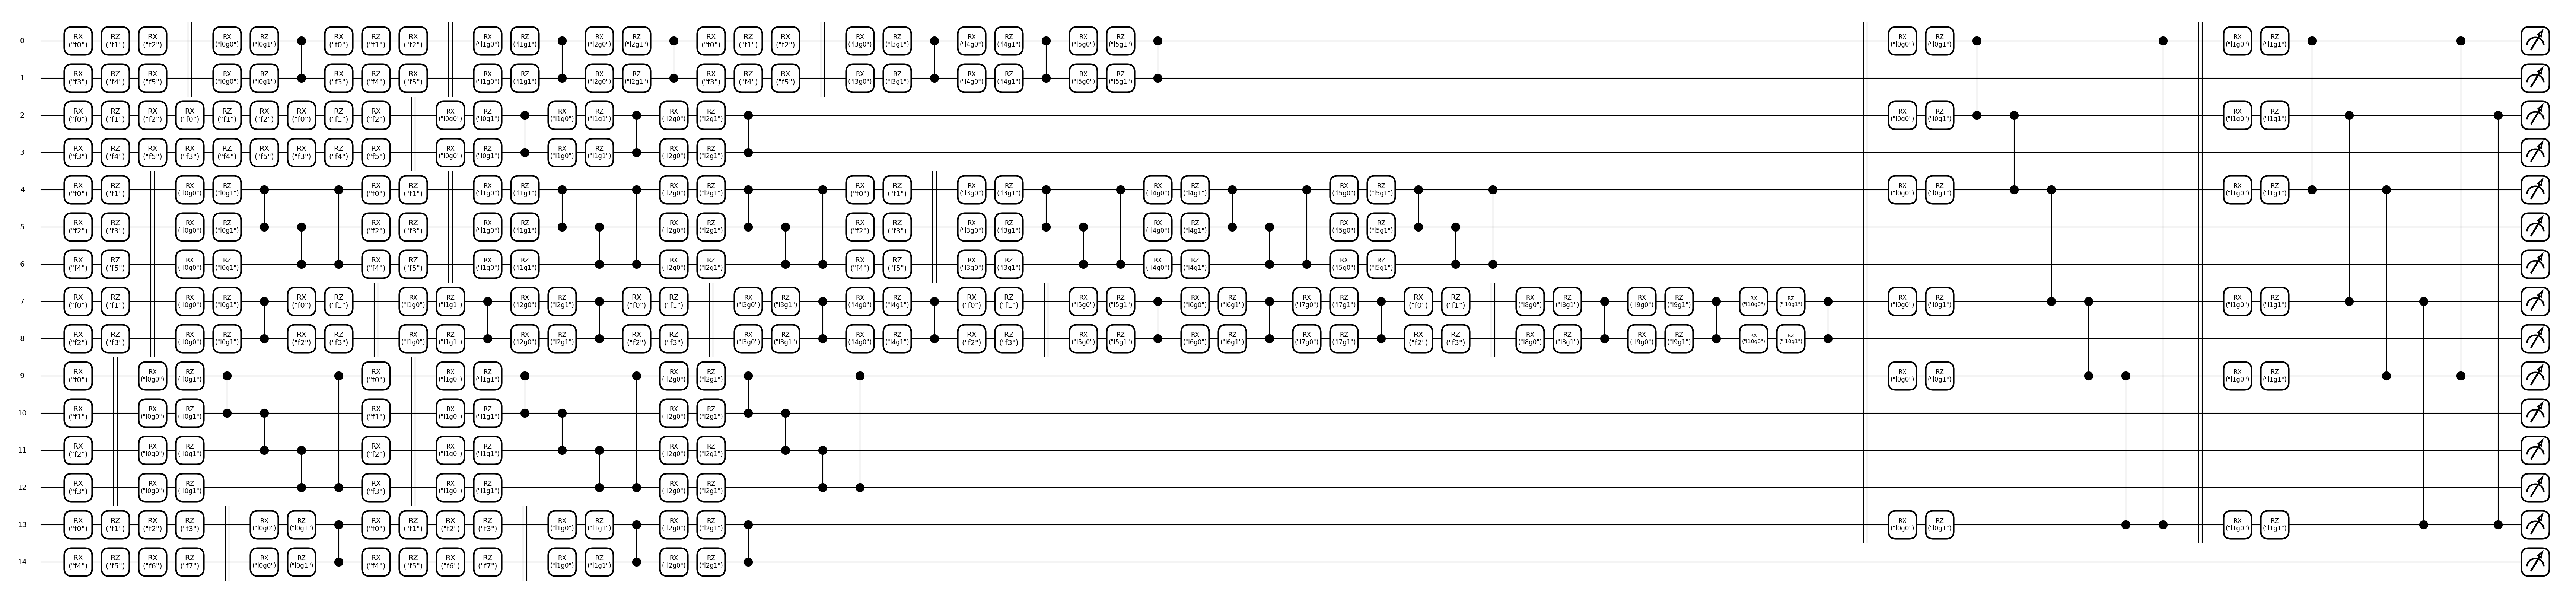

In [12]:
model = CoherentECOC(meta_layers=[1,2],  templates=[1,2,3,'deep', 'wide', 'dense']).to(DEVICE)
model.initialise_ensemble(X_train, y_train, False)
model.build_coherent_circuit()

# for clf in model.classifiers:
#     qml.draw_mpl(clf.circuit)(np.zeros(clf.n_features), np.zeros(clf.weight_shapes["weights"]))

qml.draw_mpl(model.coherent_vqc.circuit)(np.zeros(model.coherent_vqc.n_features), np.zeros(model.coherent_vqc.weight_shapes["weights"]))
print(f"Model Weight Shapes: {model.coherent_vqc.weight_shapes}")

In [5]:
x = np.zeros(model.coherent_vqc.n_features)
weights = np.zeros(model.coherent_vqc.weight_shapes["weights"])
specs = qml.specs(model.coherent_vqc.circuit)(x, weights)

print(specs)

/home/edwar/.pyenv/versions/3.14.5/lib/python3.14/site-packages/pennylane/math/interface_utils.py:137: UserWarning: Contains tensors of types {'autograd', 'torch'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(


Device: default.qubit
Device wires: 15
Shots: Shots(total=None)
Level: gradient

Wire allocations: 15
Total gates: 357
Gate counts:
- RX: 147
- RZ: 127
- Barrier: 18
- CZ: 65
Measurements:
- probs(all wires): 1
Depth: 63


In [6]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import QiskitRuntimeService

In [7]:
def analyse_pennylane_qnode_for_ibm(qnode, x, weights, backend_name="ibm_boston"):

    # PennyLane-level stats
    pl_specs = qml.specs(qnode)(x, weights)
    pl_resources = pl_specs["resources"]

    # Construct tape so we get the real PennyLane wire labels
    tape = qml.workflow.construct_tape(qnode)(x, weights)
    actual_wires = list(tape.wires)

    print("Actual PennyLane wires:", actual_wires)

    # Export PennyLane -> OpenQASM -> Qiskit
    qasm_str = qml.to_openqasm(
        qnode,
        wires=actual_wires,
        measure_all=True
    )(x, weights)

    qc = QuantumCircuit.from_qasm_str(qasm_str)

    # IBM backend
    service = QiskitRuntimeService(
        channel="ibm_quantum_platform",
        token="yFaEKPAcJ9jQwMNDQKtBiy34aL77m-AFu5nsg1jGNQ4l",
    )
    backend = service.backend(backend_name)

    tqc = transpile(
        qc,
        backend=backend,
        optimization_level=3,
        seed_transpiler=42
    )

    def two_qubit_gate_count(circuit):
        return sum(1 for inst in circuit.data if len(inst.qubits) == 2)

    def two_qubit_depth(circuit):
        return circuit.depth(
            filter_function=lambda inst: len(inst.qubits) == 2
        )

    return {
        "actual_pennylane_wires": actual_wires,

        "pennylane_depth": pl_resources.depth,
        "pennylane_num_gates": pl_resources.num_gates,
        "pennylane_gate_types": dict(pl_resources.gate_types),
        "pennylane_gate_sizes": dict(pl_resources.gate_sizes),

        "raw_qiskit_depth": qc.depth(),
        "raw_qiskit_ops": dict(qc.count_ops()),

        "transpiled_depth": tqc.depth(),
        "transpiled_ops": dict(tqc.count_ops()),
        "two_qubit_gate_count": two_qubit_gate_count(tqc),
        "two_qubit_depth": two_qubit_depth(tqc),

        "qiskit_circuit": qc,
        "transpiled_circuit": tqc,
    }

x = np.zeros(model.coherent_vqc.n_features)
weights = np.zeros(model.coherent_vqc.weight_shapes["weights"])

stats = analyse_pennylane_qnode_for_ibm(
    model.coherent_vqc.circuit,
    x,
    weights,
    backend_name="ibm_kingston"
)

for k, v in stats.items():
    if "circuit" not in k:
        print(k, ":", v)

qiskit_runtime_service._discover_account:WARNING:2026-06-30 20:17:35,563: Loading account with the given token. A saved account will not be used.


Actual PennyLane wires: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


qiskit_runtime_service.__init__:WARNING:2026-06-30 20:17:38,878: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-30 20:17:38,878: Using instance: open-instance, plan: open


actual_pennylane_wires : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
pennylane_depth : 63
pennylane_num_gates : 357
pennylane_gate_types : {'RX': 147, 'RZ': 127, 'Barrier': 18, 'CZ': 65}
pennylane_gate_sizes : {1: 274, 2: 76, 3: 3, 4: 2, 6: 2}
raw_qiskit_depth : 55
raw_qiskit_ops : {'rx': 147, 'rz': 127, 'cz': 65, 'measure': 15}
transpiled_depth : 154
transpiled_ops : {'sx': 282, 'rz': 221, 'cz': 121, 'measure': 15, 'x': 1}
two_qubit_gate_count : 121
two_qubit_depth : 58
